Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Load Dataset

In [4]:
df = pd.read_csv("Walmart_Sales.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


Step 3: Check Dataset

In [5]:
print(df.head())
print(df.isnull().sum())
print(df.info())
print(df.describe())
print("Rows and Columns:", df.shape)
print(df.columns)
print("Duplicate Rows:", df.duplicated().sum())

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         

Step 4: Convert Date Column

In [6]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

Step 5: Create Year and Month Columns

In [7]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

Step 6: Save Cleaned Dataset

In [8]:
df.to_csv("cleaned_data.csv", index=False)

Step 7: Data Visualization 
            

1.Top 10 Stores by Sales

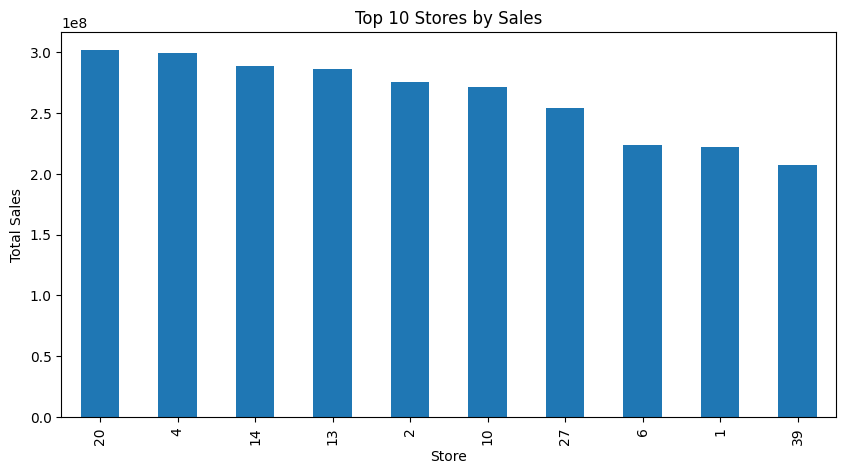

In [9]:
top_stores = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
top_stores.head(10).plot(kind='bar')
plt.title('Top 10 Stores by Sales')
plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.savefig('charts/top_stores.png')
plt.show()

2. Monthly Sales Trend

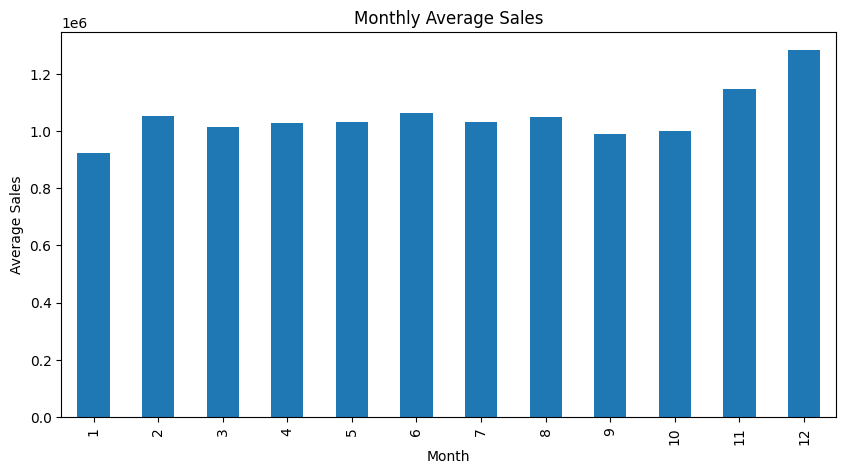

In [10]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='bar')
plt.title('Monthly Average Sales')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.savefig('charts/monthly_sales.png')
plt.show()

3. Holiday vs Non-Holiday Sales

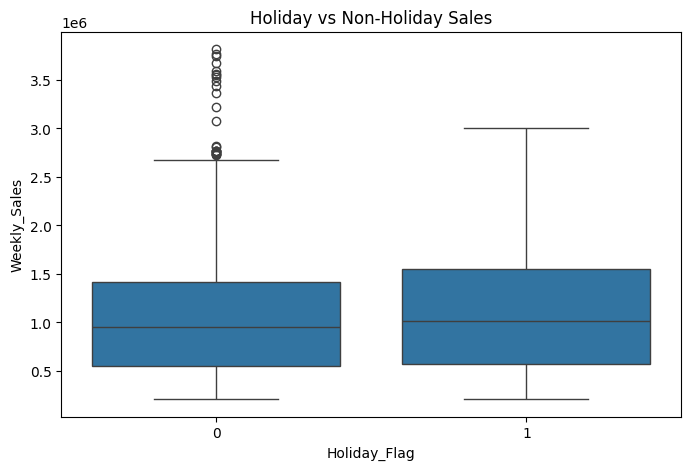

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.title('Holiday vs Non-Holiday Sales')
plt.savefig('charts/holiday_sales.png')
plt.show()

4. Sales Distribution

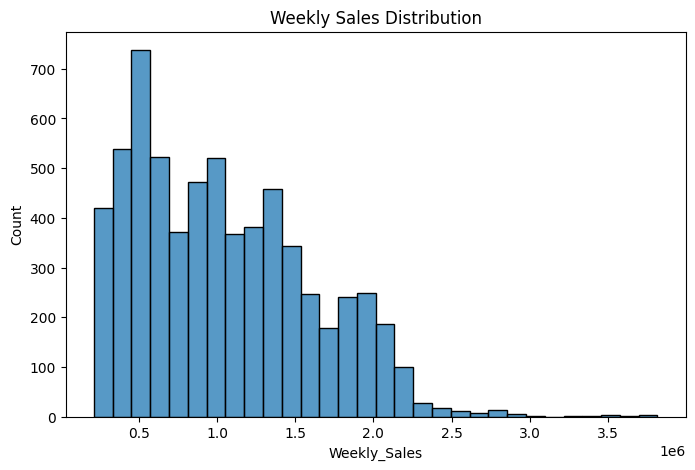

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['Weekly_Sales'], bins=30)
plt.title('Weekly Sales Distribution')
plt.savefig('charts/distribution.png')
plt.show()

5. Correlation Heatmap

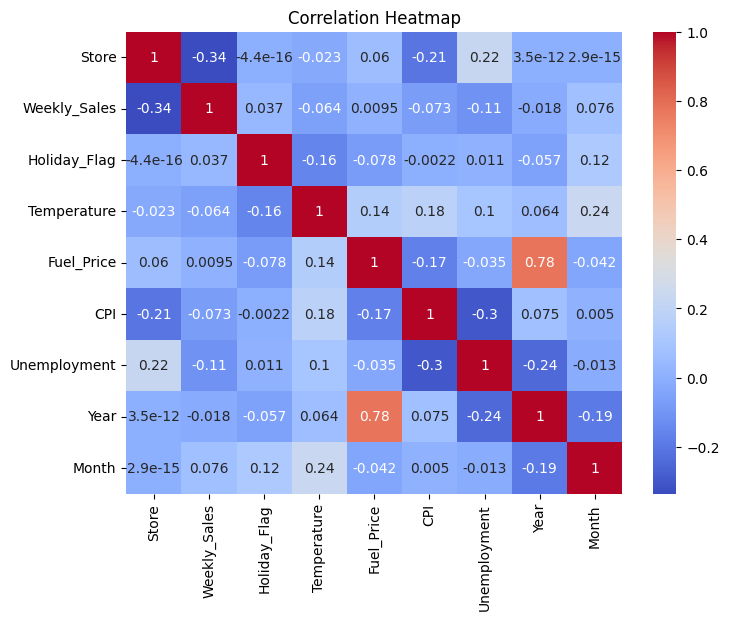

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('charts/heatmap.png')
plt.show()

6. Temperature vs Sales

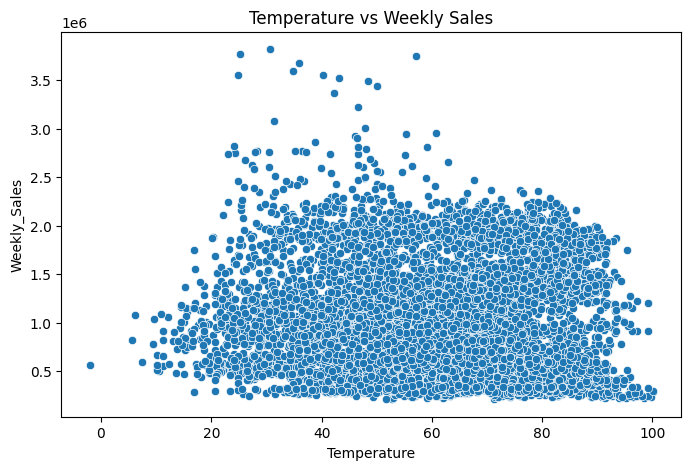

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df)
plt.title('Temperature vs Weekly Sales')
plt.savefig('charts/temp_sales.png')
plt.show()

7. Fuel Price vs Sales

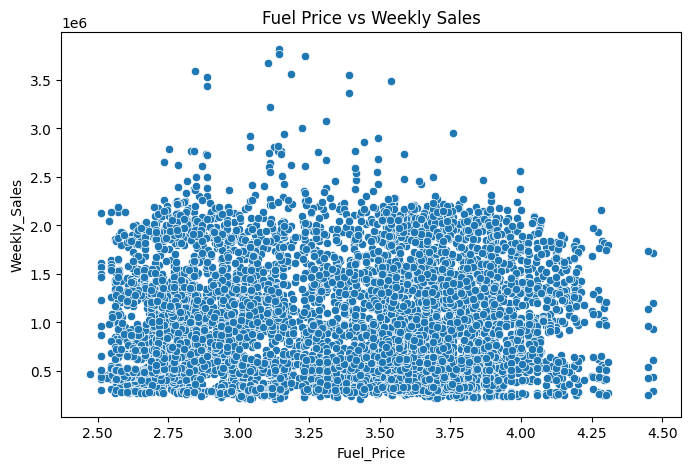

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=df)
plt.title('Fuel Price vs Weekly Sales')
plt.savefig('charts/fuel_sales.png')
plt.show()

Step 8: Final Summary

In [16]:
print("Data Cleaning Completed")
print("No Missing Values:", df.isnull().sum().sum() == 0)
print("No Duplicate Rows:", df.duplicated().sum() == 0)
print("Cleaned Dataset Shape:", df.shape)

Data Cleaning Completed
No Missing Values: True
No Duplicate Rows: True
Cleaned Dataset Shape: (6435, 10)
